In [25]:
import pyscf
import openfermionpyscf
import openfermion as of
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [29]:
dists = np.linspace(0.8, 6, 21)

orbenes = np.zeros((6, len(dists)))

for i, dist in tqdm(enumerate(dists)):

    
    geometry = [["Li", (0, 0, 0)],
                ["H", (0, 0, dist)]]
    
    mol = of.MolecularData(
            geometry=geometry,
            basis="sto-3g",
            multiplicity=1,
            charge=0
        )
    mol = openfermionpyscf.run_pyscf(mol, run_scf=True, run_fci=False, run_cisd=False)
    orbenes[:, i] = mol.orbital_energies

21it [00:21,  1.02s/it]


Text(0, 0.5, 'Orbital energies')

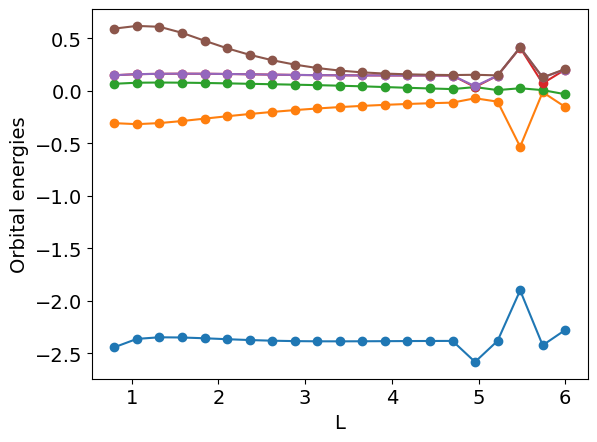

In [30]:
plt.rcParams.update({"font.size":14})
plt.plot(dists, orbenes[0, :], "o-")
plt.plot(dists, orbenes[1, :], "o-")
plt.plot(dists, orbenes[2, :], "o-")
plt.plot(dists, orbenes[3, :], "o-")
plt.plot(dists, orbenes[4, :], "o-")
plt.plot(dists, orbenes[5, :], "o-")
plt.xlabel("L")
plt.ylabel("Orbital energies")

In [15]:
print(mol.orbital_energies)
print(mol.orbital_energies[2] - mol.orbital_energies[1])

[-2.10244138e+00 -3.28480474e-01  1.16027857e-03  3.02784897e-01
  3.02784897e-01  3.03493832e-01]
0.329640752856988
